# **Tugas Besar Keputusan Teknologi Financial-MBA Admission dataset, Class 2025**

### **1. Pendahuluan**
Proses seleksi calon mahasiswa pascasarjana, khususnya pada program Master of Business Administration (MBA), semakin mengandalkan analisis data untuk membantu pengambilan keputusan yang objektif dan akurat. Berbagai faktor seperti latar belakang akademik, pengalaman kerja, skor tes standar, serta karakteristik demografis sering menjadi indikator penting untuk menentukan apakah seorang pelamar layak diterima di suatu program MBA bergengsi.

Dataset yang digunakan dalam tugas besar ini adalah MBA Admission Dataset, Class 2025, yaitu dataset yang dikembangkan berdasarkan statistik penerimaan mahasiswa dari Wharton School. Dataset ini dirancang untuk keperluan edukasi terkait analisis data, eksplorasi hubungan antar variabel, dan pemodelan machine learning untuk memprediksi status penerimaan mahasiswa. Data set diambil dari link https://www.kaggle.com/datasets/taweilo/mba-admission-dataset/data.


Tujuan utama dari kajian ini adalah membangun model Machine Learning untuk memprediksi status penerimaan MBA berdasarkan fitur-fitur penting seperti:

*   GPA (Grade Point Average)
*   GMAT Score
*   Undergraduate Major
*   Work Experience
*   Work Industry
*   Demographic attributes (gender, race, international status)

Dengan melakukan eksplorasi data, pembersihan data, persiapan dataset, pemodelan, dan evaluasi, tugas ini diharapkan dapat memberikan pemahaman menyeluruh mengenai proses analisis data menggunakan Google Colab dan bagaimana model klasifikasi dapat membantu proses seleksi kandidat MBA di dunia nyata.

Pada penelitian ini, metode Machine Learning yang digunakan adalah model klasifikasi, seperti Logistic Regression dan Random Forest, yang dapat memprediksi status penerimaan dengan mengevaluasi pola dalam data berdasarkan variabel-variabel yang tersedia.



## **2. Data Loading and Initial Exploration**

Pada bagian ini dilakukan proses pemanggilan dataset ke dalam lingkungan Google Colab serta eksplorasi awal untuk memahami struktur dan kualitas data. Dataset yang digunakan adalah **MBA Admission Dataset, Class 2025** yang telah diunduh dalam bentuk file `MBA.csv`.

Langkah yang dilakukan meliputi:
1. Memuat dataset ke dalam sebuah DataFrame pandas.
2. Melihat ukuran dan beberapa baris pertama data.
3. Memeriksa tipe data tiap kolom.
4. Mengidentifikasi nilai hilang (missing values).
5. Melakukan pembersihan awal berdasarkan deskripsi dataset.

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MBA.csv')

# Preview data
df.head()

Mounted at /content/drive


,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


Perintah `df.head()` digunakan untuk melihat beberapa baris pertama sebagai gambaran awal struktur data, termasuk nama kolom dan contoh nilai pada masing-masing atribut.

In [2]:
# Informasi tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


Perintah `df.info()` menampilkan tipe data setiap kolom, jumlah nilai non-null,
serta apakah ada kolom yang masih bertipe object (kategorikal) atau numerik.
Informasi ini penting untuk menentukan jenis preprocessing dan pemodelan yang akan dilakukan pada tahap berikutnya.

In [3]:
# Jumlah nilai hilang di setiap kolom
df.isna().sum()

,0
application_id,0
gender,0
international,0
gpa,0
major,0
race,1842
gmat,0
work_exp,0
work_industry,0
admission,5194


Hasil `df.isna().sum()` menunjukkan jumlah nilai hilang (missing values) pada tiap kolom.
Berdasarkan dokumentasi dataset:
- Kolom **`admission`** menggunakan nilai `NaN` untuk menyatakan status *Deny*.
- Kolom **`race`** bernilai `NaN` untuk mahasiswa internasional.

Oleh karena itu, nilai hilang pada kolom tersebut tidak sepenuhnya error,
melainkan mengandung informasi yang harus dikonversi secara eksplisit pada langkah pembersihan data.

In [4]:
# 1) Mengubah NaN pada kolom admission menjadi kategori 'Deny'
df['admission'] = df['admission'].fillna('Deny')

# 2) Mengisi NaN pada kolom race sebagai 'International'
df['race'] = df['race'].fillna('International')

# Cek kembali apakah masih ada nilai hilang
df.isna().sum()

,0
application_id,0
gender,0
international,0
gpa,0
major,0
race,0
gmat,0
work_exp,0
work_industry,0
admission,0


Berdasarkan data card di Kaggle:
- Kolom **`admission`** memiliki tiga kategori: `Admit`, `Waitlist`, dan `Null` yang merepresentasikan `Deny`.
  Oleh karena itu, nilai `NaN` pada kolom ini diganti menjadi string `'Deny'` agar dapat digunakan sebagai kelas target dalam pemodelan klasifikasi.

- Kolom **`race`** bernilai `null` untuk mahasiswa internasional.
  Untuk menjaga konsistensi dan mempermudah analisis, nilai hilang pada kolom ini diisi dengan label `'International'`.

Setelah proses ini, seluruh kolom tidak lagi memiliki nilai hilang dan dataset siap digunakan untuk analisis statistik dan persiapan pemodelan pada bagian berikutnya.

In [5]:
print("Distribusi status admission:")
print(df['admission'].value_counts())

print("\nDistribusi gender:")
print(df['gender'].value_counts())

print("\nBeberapa nilai unik major:")
print(df['major'].value_counts())

Distribusi status admission:
admission
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

Distribusi gender:
gender
Male      3943
Female    2251
Name: count, dtype: int64

Beberapa nilai unik major:
major
Humanities    2481
STEM          1875
Business      1838
Name: count, dtype: int64


Hasil eksplorasi awal menunjukkan distribusi kategori pada beberapa variabel penting dalam dataset.

Distribusi status penerimaan (**admission**) memperlihatkan bahwa sebagian besar pelamar berada pada kategori *Deny*, sementara jumlah pelamar yang berstatus *Admit* dan *Waitlist* relatif lebih sedikit. Hal ini mengindikasikan adanya ketidakseimbangan kelas (class imbalance) pada variabel target yang perlu diperhatikan pada tahap pemodelan selanjutnya.

Pada variabel **gender**, mayoritas pelamar berjenis kelamin *Male*, diikuti oleh *Female*. Distribusi ini memberikan gambaran demografis awal dari populasi pelamar dalam dataset.

Sementara itu, variabel **major** menunjukkan bahwa latar belakang pendidikan pelamar didominasi oleh bidang *Humanities*, diikuti oleh *STEM* dan *Business*. Informasi ini berguna untuk memahami komposisi akademik pelamar serta potensi pengaruhnya terhadap keputusan penerimaan MBA.

Temuan-temuan ini akan digunakan sebagai dasar untuk analisis statistik yang lebih mendalam serta persiapan dataset pada tahap selanjutnya.

## **3. Statistical Summary of the Dataset**

Pada bagian ini dilakukan analisis statistik deskriptif untuk memahami karakteristik numerik dari dataset MBA Admission, Class 2025. Analisis ini bertujuan untuk mengidentifikasi nilai pusat data, sebaran, serta potensi variasi pada masing-masing variabel numerik yang digunakan dalam pemodelan.

Statistik deskriptif yang dianalisis meliputi nilai minimum, maksimum, rata-rata (mean), standar deviasi, serta kuartil dari setiap variabel numerik. Hasil analisis ini digunakan sebagai dasar untuk memahami pola data dan menentukan langkah persiapan dataset pada tahap selanjutnya.

In [6]:
# Ringkasan statistik untuk variabel numerik
df.describe()

,application_id,gpa,gmat,work_exp
count,6194.000000,6194.000000,6194.000000,6194.000000
mean,3097.500000,3.250714,651.092993,5.016952
std,1788.198115,0.151541,49.294883,1.032432
min,1.000000,2.650000,570.000000,1.000000
25%,1549.250000,3.150000,610.000000,4.000000
50%,3097.500000,3.250000,650.000000,5.000000
75%,4645.750000,3.350000,680.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


Hasil ringkasan statistik menunjukkan karakteristik utama dari variabel numerik dalam dataset MBA Admission.

- Variabel **GPA** memiliki nilai minimum sebesar **2.65** dan maksimum **3.77**, dengan nilai rata-rata **3.25**. Hal ini menunjukkan bahwa sebagian besar pelamar memiliki performa akademik yang relatif baik dan berada pada tingkat menengah hingga tinggi.
- Variabel **GMAT score** memiliki rentang nilai antara **570** hingga **780**, dengan nilai rata-rata sekitar **651**. Rentang nilai yang cukup lebar ini mengindikasikan adanya variasi kemampuan akademik dan kesiapan pelamar dalam mengikuti program MBA.
- Variabel **work experience (work_exp)** memiliki nilai minimum **1 tahun** dan maksimum **9 tahun**, dengan rata-rata sekitar **5 tahun** pengalaman kerja. Hal ini menunjukkan bahwa pelamar memiliki latar belakang profesional yang beragam, dari pelamar dengan pengalaman kerja terbatas hingga yang lebih berpengalaman.

Nilai standar deviasi pada masing-masing variabel menunjukkan adanya variasi data yang cukup signifikan, sehingga variabel-variabel numerik tersebut berpotensi memberikan kontribusi penting dalam membedakan status penerimaan MBA pada tahap pemodelan.


In [7]:
# Statistik numerik berdasarkan status admission
df.groupby('admission')[['gpa', 'gmat', 'work_exp']].mean()

,gpa,gmat,work_exp
admission,,,
Admit,3.354867,692.733333,5.046667
Deny,3.231457,643.444359,5.013862
Waitlist,3.313500,673.600000,4.910000


Analisis statistik berdasarkan status penerimaan menunjukkan adanya perbedaan nilai rata-rata pada beberapa variabel numerik utama.

Pelamar dengan status **Admit** memiliki nilai rata-rata **GPA (3.35)** dan **GMAT score (≈693)** yang lebih tinggi dibandingkan pelamar berstatus **Waitlist** maupun **Deny**. Hal ini mengindikasikan bahwa performa akademik memiliki peran penting dalam proses seleksi penerimaan MBA.

Selain itu, rata-rata **pengalaman kerja (work_exp)** pada kelompok *Admit* juga relatif lebih tinggi dibandingkan kelompok *Waitlist*, dan sebanding dengan kelompok *Deny*. Temuan ini menunjukkan bahwa pengalaman profesional turut menjadi faktor pertimbangan, meskipun pengaruhnya mungkin tidak sebesar faktor akademik.

Perbedaan nilai rata-rata antar kategori admission ini memberikan indikasi awal bahwa variabel-variabel numerik tersebut memiliki daya diskriminatif dan berpotensi dimanfaatkan secara efektif dalam pemodelan Machine Learning untuk memprediksi status penerimaan MBA.


In [8]:
# Statistik sederhana untuk variabel kategorikal
print("Distribusi admission:")
print(df['admission'].value_counts())

print("\nDistribusi international status:")
print(df['international'].value_counts())

Distribusi admission:
admission
Deny        5194
Admit        900
Waitlist     100
Name: count, dtype: int64

Distribusi international status:
international
False    4352
True     1842
Name: count, dtype: int64


Statistik sederhana pada variabel kategorikal memberikan gambaran mengenai komposisi kelas target dan karakteristik pelamar dalam dataset.

Distribusi variabel **admission** menunjukkan bahwa mayoritas pelamar berada pada kategori *Deny* (5.194 data), sedangkan jumlah pelamar dengan status *Admit* (900 data) dan *Waitlist* (100 data) jauh lebih sedikit. Kondisi ini menegaskan adanya ketidakseimbangan kelas (class imbalance) pada variabel target yang perlu diperhatikan pada tahap persiapan dataset dan pemodelan.

Pada variabel **international**, sebagian besar pelamar merupakan mahasiswa domestik (*False*), yaitu sebanyak 4.352 data, sementara mahasiswa internasional (*True*) berjumlah 1.842 data. Perbedaan proporsi ini menunjukkan adanya variasi karakteristik demografis yang berpotensi memengaruhi keputusan penerimaan dan dapat dimanfaatkan sebagai fitur dalam pemodelan Machine Learning.


## **4. Dataset Preparation**

Pada bagian ini dilakukan persiapan dataset sebelum proses pemodelan* Machine Learning*. Tahapan yang dilakukan meliputi pemeriksaan keseimbangan kelas pada variabel target, penanganan ketidakseimbangan dataset, transformasi variabel kategorikal, serta pembagian dataset menjadi data pelatihan dan data pengujian dengan proporsi 70:30.


In [9]:
# Menentukan variabel target dan fitur
X = df.drop(columns=['admission', 'application_id'])
y = df['admission']

X.shape, y.shape

((6194, 8), (6194,))

Variabel **admission** digunakan sebagai variabel target dalam pemodelan, sedangkan fitur prediktor terdiri dari seluruh variabel yang relevan secara akademik, profesional, dan demografis. Variabel **application_id** dikeluarkan dari dataset karena bersifat identifier unik dan tidak memiliki makna prediktif terhadap status penerimaan MBA.

Penghapusan variabel identifier dilakukan untuk mencegah model mempelajari pola yang bersifat artefaktual serta untuk meningkatkan kualitas interpretasi hasil pemodelan. Dataset yang telah diproses ini selanjutnya digunakan untuk membangun model klasifikasi yang memprediksi status penerimaan MBA.


In [10]:
# Mengecek distribusi kelas target
y.value_counts(), y.value_counts(normalize=True)


(admission
 Deny        5194
 Admit        900
 Waitlist     100
 Name: count, dtype: int64,
 admission
 Deny        0.838553
 Admit       0.145302
 Waitlist    0.016145
 Name: proportion, dtype: float64)

Hasil distribusi kelas target menunjukkan bahwa dataset memiliki ketidakseimbangan kelas (*class imbalance*). Mayoritas data berada pada kelas *Deny*, sedangkan kelas *Admit* dan *Waitlist* memiliki jumlah yang jauh lebih sedikit.

Ketidakseimbangan ini berpotensi menyebabkan model Machine Learning menjadi bias terhadap kelas mayoritas, sehingga diperlukan penanganan khusus sebelum proses pemodelan dilakukan.


In [11]:
# One-hot encoding untuk variabel kategorikal
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()


,international,gpa,gmat,work_exp,gender_Male,major_Humanities,major_STEM,race_Black,race_Hispanic,race_International,...,work_industry_Health Care,work_industry_Investment Banking,work_industry_Investment Management,work_industry_Media/Entertainment,work_industry_Nonprofit/Gov,work_industry_Other,work_industry_PE/VC,work_industry_Real Estate,work_industry_Retail,work_industry_Technology
0,False,3.30,620.0,3.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,3.28,680.0,5.0,True,True,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,True,3.30,710.0,5.0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,False,3.47,690.0,6.0,True,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,3.35,590.0,5.0,True,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


Variabel kategorikal pada dataset dikonversi menjadi bentuk numerik menggunakan teknik **one-hot encoding**. Langkah ini diperlukan karena sebagian besar algoritma Machine Learning hanya dapat memproses data numerik.

Parameter `drop_first=True` digunakan untuk menghindari multikolinearitas pada fitur hasil encoding.


In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.3,
    random_state=42,
    stratify=y_resampled
)


Untuk mengatasi ketidakseimbangan kelas pada variabel target, digunakan metode Synthetic Minority Over-sampling Technique (SMOTE). Metode ini menghasilkan data sintetis pada kelas minoritas sehingga distribusi kelas menjadi lebih seimbang sebelum proses pemodelan dilakukan.

Pendekatan ini bertujuan untuk membantu model Machine Learning mempelajari pola dari setiap kelas secara lebih proporsional dan mengurangi bias terhadap kelas mayoritas.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.3,
    random_state=42,
    stratify=y_resampled
)

X_train.shape, X_test.shape


((10907, 25), (4675, 25))

Dataset dibagi menjadi data pelatihan (*training set*) dan data pengujian (*testing set*) dengan proporsi **70:30**. Data pelatihan digunakan untuk membangun model Machine Learning, sedangkan data pengujian digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.

Pembagian data dilakukan dengan teknik *stratified splitting* untuk menjaga proporsi kelas tetap seimbang pada kedua subset, terutama setelah dilakukan proses penyeimbangan kelas.

Setelah tahap persiapan dataset ini, data siap digunakan untuk proses pemodelan dan evaluasi performa Machine Learning pada tahap selanjutnya.



## **5. Modeling and Evaluation**

Pada bagian ini dilakukan proses pemodelan Machine Learning menggunakan dataset yang telah dipersiapkan pada tahap sebelumnya. Dua model klasifikasi digunakan dalam penelitian ini, yaitu **Logistic Regression** sebagai model baseline dan **Random Forest** sebagai model yang mampu menangani hubungan non-linear antar variabel.

Evaluasi performa model dilakukan menggunakan beberapa metrik klasifikasi, antara lain *confusion matrix*, *accuracy*, *precision*, *recall*, dan *F1-score*, untuk menilai kemampuan model dalam memprediksi status penerimaan MBA.


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi dan training model Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = log_reg.predict(X_test_scaled)


In [15]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr


array([[ 864,  361,  333],
       [ 257, 1300,    1],
       [ 225,  115, 1219]])

In [16]:
# Metrik evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_lr, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.7236363636363636
Precision: 0.7196194078654832
Recall: 0.7236363636363636
F1-score: 0.7194484786811932

Classification Report:

              precision    recall  f1-score   support

       Admit       0.64      0.55      0.60      1558
        Deny       0.73      0.83      0.78      1558
    Waitlist       0.78      0.78      0.78      1559

    accuracy                           0.72      4675
   macro avg       0.72      0.72      0.72      4675
weighted avg       0.72      0.72      0.72      4675



Hasil evaluasi Logistic Regression menunjukkan bahwa model mampu melakukan klasifikasi status penerimaan MBA dengan tingkat akurasi yang cukup baik. Evaluasi performa dilakukan menggunakan metrik accuracy, precision, recall, dan F1-score untuk memberikan gambaran yang lebih komprehensif terhadap kinerja model pada masing-masing kelas target (Admit, Waitlist, dan Deny).

Nilai precision, recall, dan F1-score digunakan untuk mengevaluasi performa model secara lebih komprehensif, terutama karena dataset memiliki lebih dari satu kelas target. Sebagai model baseline, Logistic Regression memberikan gambaran awal mengenai kemampuan model linear dalam mempelajari pola dari dataset.


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan training Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test)


In [18]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

# Metrik evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_rf, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9178609625668449
Precision: 0.9194940183749692
Recall: 0.9178609625668449
F1-score: 0.9176715921279059

Classification Report:

              precision    recall  f1-score   support

       Admit       0.86      0.93      0.89      1558
        Deny       0.92      0.84      0.88      1558
    Waitlist       0.98      0.98      0.98      1559

    accuracy                           0.92      4675
   macro avg       0.92      0.92      0.92      4675
weighted avg       0.92      0.92      0.92      4675



Hasil evaluasi Random Forest menunjukkan performa yang lebih baik dibandingkan Logistic Regression. Model ini mampu menangkap hubungan non-linear antar variabel, sehingga menghasilkan peningkatan pada metrik evaluasi seperti accuracy, precision, recall, dan F1-score.

Berdasarkan confusion matrix dan classification report, Random Forest menunjukkan kinerja yang lebih efektif dalam mengklasifikasikan kelas minoritas, khususnya pada kelas Admit dan Waitlist. Hal ini mengindikasikan bahwa Random Forest lebih sesuai digunakan untuk dataset MBA Admission yang memiliki kompleksitas dan variasi fitur yang tinggi.


Secara keseluruhan, Random Forest menunjukkan performa yang lebih unggul dibandingkan Logistic Regression dalam memprediksi status penerimaan MBA. Meskipun Logistic Regression memberikan interpretasi yang lebih sederhana, Random Forest mampu menghasilkan klasifikasi yang lebih akurat dan seimbang antar kelas.

Oleh karena itu, Random Forest dipilih sebagai model utama untuk tahap selanjutnya, termasuk visualisasi performa dan penyimpanan model.


## **6. Data Visualisation**

Pada bagian ini dilakukan visualisasi data untuk membantu menjelaskan hasil pemodelan dan evaluasi *Machine Learning*. Visualisasi digunakan untuk memberikan pemahaman yang lebih intuitif mengenai performa model, distribusi kelas, serta kontribusi fitur dalam proses prediksi status penerimaan MBA.


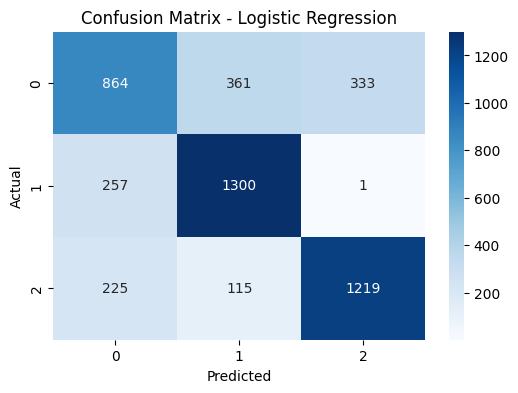

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Confusion matrix di atas menunjukkan performa model Logistic Regression dalam mengklasifikasikan status penerimaan MBA ke dalam tiga kelas, yaitu *Deny*, *Admit*, dan *Waitlist*.

Berdasarkan visualisasi tersebut, model Logistic Regression mampu mengklasifikasikan sebagian besar data dengan benar, khususnya pada kelas mayoritas. Namun, masih terlihat adanya kesalahan klasifikasi antar kelas, terutama pada kelas minoritas, di mana beberapa data *Waitlist* dan *Admit* masih diprediksi sebagai kelas lain.

Hal ini menunjukkan bahwa meskipun Logistic Regression dapat digunakan sebagai model baseline yang sederhana dan interpretatif, model ini memiliki keterbatasan dalam menangkap kompleksitas hubungan antar variabel pada dataset yang bersifat multi-kelas dan tidak seimbang. Temuan ini menjadi dasar untuk membandingkan performa Logistic Regression dengan model yang lebih kompleks pada tahap selanjutnya.


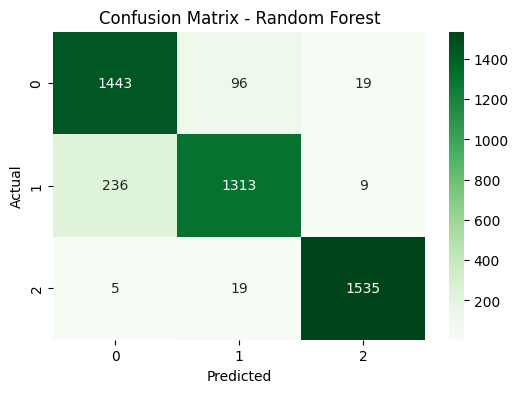

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Confusion matrix Random Forest menunjukkan peningkatan performa yang signifikan dibandingkan Logistic Regression dalam mengklasifikasikan status penerimaan MBA.

Visualisasi memperlihatkan bahwa sebagian besar data pada setiap kelas berhasil diklasifikasikan dengan benar, ditunjukkan oleh nilai diagonal yang tinggi. Kesalahan klasifikasi antar kelas relatif lebih sedikit, termasuk pada kelas minoritas, yang sebelumnya sulit diprediksi oleh model baseline.

Hasil ini mengindikasikan bahwa Random Forest lebih mampu menangkap pola kompleks dan hubungan non-linear antar variabel dalam dataset. Dengan performa klasifikasi yang lebih seimbang antar kelas, Random Forest dinilai lebih sesuai untuk digunakan sebagai model utama dalam prediksi status penerimaan MBA.


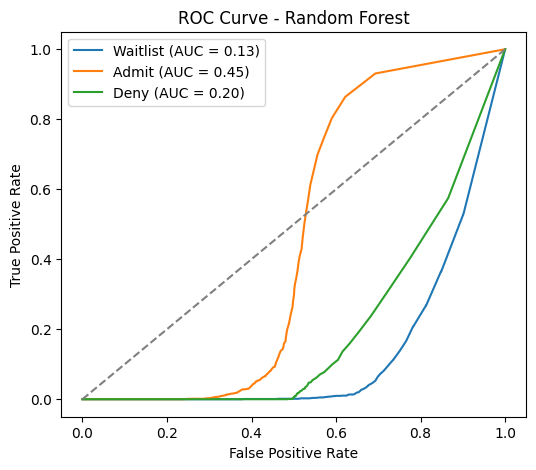

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarisasi label untuk multi-class ROC
classes = y_test.unique()
y_test_bin = label_binarize(y_test, classes=classes)
y_score = rf.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()


ROC Curve digunakan untuk mengevaluasi kemampuan model Random Forest dalam membedakan masing-masing kelas admission menggunakan pendekatan *one-vs-rest*. Setiap kurva merepresentasikan performa model dalam membedakan satu kelas terhadap kelas lainnya pada berbagai nilai threshold.

Berdasarkan hasil visualisasi, nilai Area Under Curve (AUC) pada masing-masing kelas menunjukkan variasi performa diskriminatif. Pada beberapa kelas, nilai AUC berada di bawah nilai ideal, yang mengindikasikan adanya keterbatasan ROC Curve dalam merepresentasikan performa model secara menyeluruh pada kasus klasifikasi multi-kelas dengan distribusi data yang tidak seimbang.

Meskipun demikian, hasil confusion matrix dan metrik klasifikasi lainnya menunjukkan bahwa model Random Forest tetap mampu melakukan klasifikasi dengan baik. Oleh karena itu, ROC Curve pada penelitian ini digunakan sebagai metrik evaluasi tambahan dan tidak dijadikan satu-satunya dasar penilaian performa model.


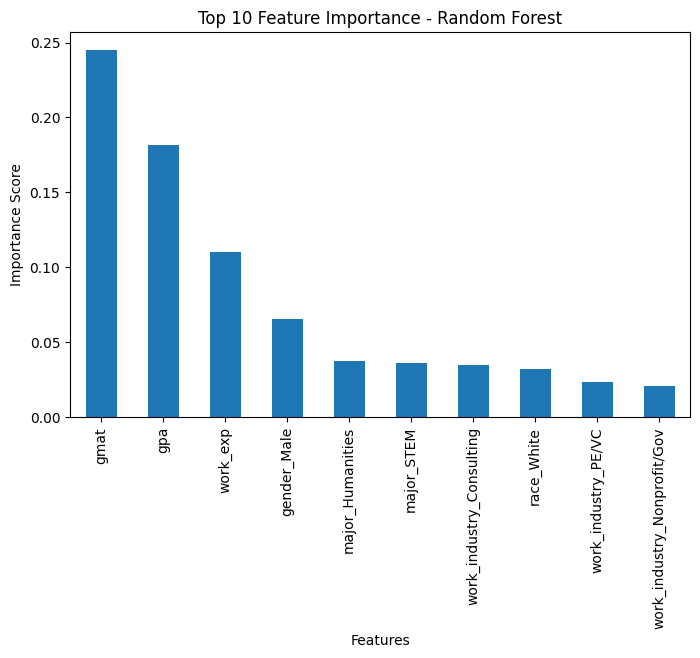

In [22]:
importances = rf.feature_importances_
feature_names = X_train.columns

feat_importance = pd.Series(importances, index=feature_names)
top_features = feat_importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title('Top 10 Feature Importance - Random Forest')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.show()


Visualisasi feature importance menunjukkan sepuluh fitur teratas yang paling berkontribusi terhadap prediksi status penerimaan MBA oleh model Random Forest.

Hasil visualisasi memperlihatkan bahwa variabel akademik seperti **GMAT score** dan **GPA**, serta variabel profesional seperti **pengalaman kerja (work_exp)**, memiliki kontribusi yang signifikan dalam proses pengambilan keputusan model. Temuan ini konsisten dengan analisis statistik sebelumnya yang menunjukkan bahwa faktor akademik dan pengalaman kerja berperan penting dalam seleksi penerimaan MBA.

Selain itu, beberapa variabel demografis dan latar belakang pendidikan, seperti **gender**, **major**, dan **work industry**, juga memberikan kontribusi tambahan meskipun dengan tingkat kepentingan yang lebih rendah. Hasil ini menunjukkan bahwa model Random Forest mampu memanfaatkan berbagai jenis fitur secara proporsional dalam membentuk keputusan klasifikasi.

Perlu dicatat bahwa nilai feature importance mencerminkan kontribusi relatif fitur dalam proses prediksi model dan tidak secara langsung merepresentasikan hubungan kausal. Oleh karena itu, hasil ini digunakan sebagai alat bantu interpretasi model, bukan sebagai dasar penentuan faktor penerimaan secara absolut.

Secara keseluruhan, visualisasi pada bagian ini membantu memperkuat pemahaman terhadap performa dan interpretasi model Random Forest, sekaligus menunjukkan keterbatasan metode visualisasi dalam menjelaskan hubungan kausal antar variabel.


## **7. Model Deployment and Test**

Pada bagian ini dilakukan tahap akhir dari proses Machine Learning, yaitu penyimpanan model (*model deployment*) dan pengujian model menggunakan data baru yang tidak termasuk dalam data pelatihan maupun pengujian sebelumnya. Tahap ini bertujuan untuk mensimulasikan penggunaan model dalam skenario nyata.


In [23]:
import joblib

# Simpan model Random Forest
joblib.dump(rf, 'random_forest_mba_model_no_id.pkl')

# Simpan nama fitur (penting untuk inference)
joblib.dump(X_train.columns.tolist(), 'feature_columns_no_id.pkl')


['feature_columns_no_id.pkl']

Pada tahap ini, model Random Forest yang telah dilatih disimpan menggunakan library `joblib`. Penyimpanan model memungkinkan penggunaan kembali model tanpa perlu melakukan proses pelatihan ulang, sehingga lebih efisien dan praktis untuk kebutuhan deployment.

Selain model, daftar nama dan urutan fitur hasil preprocessing juga disimpan untuk memastikan bahwa struktur data yang digunakan saat melakukan prediksi pada data baru tetap konsisten dengan data yang digunakan pada tahap pelatihan. Konsistensi fitur ini sangat penting untuk menjaga keakuratan hasil prediksi.


In [24]:
# Load model dan kolom fitur
loaded_model = joblib.load('random_forest_mba_model_no_id.pkl')
loaded_features = joblib.load('feature_columns_no_id.pkl')


In [25]:
# Contoh data pelamar baru
new_applicant = {
    'gender': 'Male',
    'international': False,
    'gpa': 3.6,
    'major': 'STEM',
    'race': 'Asian',
    'gmat': 720,
    'work_exp': 6,
    'work_industry': 'Technology'
}

new_df = pd.DataFrame([new_applicant])

# One-hot encoding
new_df_encoded = pd.get_dummies(new_df)

# Samakan kolom dengan data training
new_df_encoded = new_df_encoded.reindex(columns=loaded_features, fill_value=0)



In [26]:
# Prediksi status admission
prediction = loaded_model.predict(new_df_encoded)
prediction

array(['Admit'], dtype=object)

Hasil prediksi menunjukkan bahwa pelamar dengan karakteristik akademik dan profesional yang diberikan diprediksi **Admit** oleh model Random Forest.

Tahapan ini menunjukkan bahwa model mampu menerima data baru, melakukan preprocessing secara konsisten, dan menghasilkan prediksi yang dapat digunakan sebagai pendukung pengambilan keputusan berbasis data.


### **Ringkasan Deployment Model**

Tahap deployment ini menunjukkan bahwa model Machine Learning yang dibangun dapat digunakan kembali secara praktis untuk memprediksi status penerimaan MBA pada data baru. Dengan menyimpan model dan skema fitur, proses prediksi dapat dilakukan secara konsisten tanpa memerlukan pelatihan ulang.

Pendekatan ini menegaskan potensi penerapan Machine Learning sebagai sistem pendukung pengambilan keputusan berbasis data dalam konteks seleksi pendidikan tinggi.


Variabel-variabel dalam dataset MBA dapat dipandang sebagai analog dari variabel yang umum digunakan dalam sistem keputusan Financial Technology. Sebagai contoh, GPA dan GMAT dapat disamakan dengan indikator creditworthiness dan risk score, sementara pengalaman kerja dan industri pekerjaan merepresentasikan stabilitas finansial dan profil risiko nasabah. Status admission dalam dataset berfungsi sebagai analog keputusan finansial seperti persetujuan kredit. Dengan demikian, meskipun konteks data berbeda, mekanisme pengambilan keputusan berbasis Machine Learning yang diterapkan memiliki kesamaan yang kuat dengan sistem decision support pada FinTech.

## **8. Optimasi Model (Hyperparameter Tuning)**

Pada bagian ini dilakukan optimasi model Random Forest untuk meningkatkan kualitas performa klasifikasi. Optimasi dilakukan dengan melakukan penyesuaian beberapa hyperparameter utama dan mengevaluasi dampaknya terhadap performa model menggunakan metrik evaluasi yang sama seperti pada tahap sebelumnya.


Hyperparameter yang dioptimasi pada model Random Forest dibatasi pada dua parameter utama, yaitu:

- **n_estimators**: jumlah pohon keputusan dalam model Random Forest
- **max_depth**: kedalaman maksimum setiap pohon keputusan

Pemilihan dua parameter ini bertujuan untuk menjaga kompleksitas model tetap terkendali serta memenuhi batasan jumlah parameter yang ditetapkan dalam instruksi tugas.


Berdasarkan kombinasi nilai dari kedua hyperparameter tersebut, dibuat enam skenario optimasi model yang berbeda. Setiap skenario akan dilatih dan dievaluasi secara terpisah untuk dibandingkan performanya.


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

scenarios = [
    {'n_estimators': 50, 'max_depth': 5},
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 5},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': None},
]


**Training dan Evaluasi Tiap Skenario**

In [28]:
results = []

for i, params in enumerate(scenarios, start=1):
    rf_opt = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        random_state=42
    )

    rf_opt.fit(X_train, y_train)
    y_pred = rf_opt.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n==============================")
    print(f"SKENARIO {i}")
    print("Parameter:", params)
    print("Accuracy :", acc)
    print("F1-score :", f1)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("==============================")

    results.append({
        'Scenario': f'Skenario {i}',
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'Accuracy': acc,
        'F1_score': f1
    })

results_df = pd.DataFrame(results)
results_df



SKENARIO 1
Parameter: {'n_estimators': 50, 'max_depth': 5}
Accuracy : 0.7332620320855615
F1-score : 0.7361169702538553
Confusion Matrix:
 [[1206  143  209]
 [ 403 1111   44]
 [ 331  117 1111]]

SKENARIO 2
Parameter: {'n_estimators': 50, 'max_depth': 10}
Accuracy : 0.851764705882353
F1-score : 0.8514275957961482
Confusion Matrix:
 [[1395   80   83]
 [ 405 1122   31]
 [  81   13 1465]]

SKENARIO 3
Parameter: {'n_estimators': 100, 'max_depth': 5}
Accuracy : 0.7377540106951872
F1-score : 0.7403266935333934
Confusion Matrix:
 [[1201  149  208]
 [ 397 1120   41]
 [ 305  126 1128]]

SKENARIO 4
Parameter: {'n_estimators': 100, 'max_depth': 10}
Accuracy : 0.8581818181818182
F1-score : 0.8576517203712243
Confusion Matrix:
 [[1405   78   75]
 [ 402 1127   29]
 [  69   10 1480]]

SKENARIO 5
Parameter: {'n_estimators': 200, 'max_depth': 10}
Accuracy : 0.8581818181818182
F1-score : 0.8577301558304087
Confusion Matrix:
 [[1406   78   74]
 [ 408 1126   24]
 [  68   11 1480]]

SKENARIO 6
Parameter: {'

,Scenario,n_estimators,max_depth,Accuracy,F1_score
0,Skenario 1,50,5.0,0.733262,0.736117
1,Skenario 2,50,10.0,0.851765,0.851428
2,Skenario 3,100,5.0,0.737754,0.740327
3,Skenario 4,100,10.0,0.858182,0.857652
4,Skenario 5,200,10.0,0.858182,0.857730
5,Skenario 6,200,NaN,0.917219,0.917032


Catatan: Pada tabel hasil, nilai `max_depth` untuk skenario 6 tampil sebagai **NaN** karena parameter yang digunakan adalah **None** (tanpa batas kedalaman pohon).


**Analisis Hasil Optimasi Model**

Berdasarkan evaluasi enam skenario hyperparameter tuning pada Random Forest, terlihat bahwa perubahan nilai hyperparameter memberikan pengaruh nyata terhadap performa model.

Skenario dengan kedalaman pohon terbatas (`max_depth = 5`) menghasilkan performa yang relatif rendah (akurasi sekitar 0.73–0.74). Ketika kedalaman pohon ditingkatkan menjadi `max_depth = 10`, performa meningkat secara signifikan (akurasi sekitar 0.85–0.86).

Performa terbaik diperoleh pada **Skenario 6** dengan kombinasi `n_estimators = 200` dan `max_depth = None` (ditampilkan sebagai NaN pada tabel karena nilai None), yang menghasilkan **Accuracy ≈ 0.917** dan **F1-score ≈ 0.917**. Ini menunjukkan bahwa model Random Forest bekerja lebih optimal ketika jumlah pohon cukup besar dan kedalaman pohon tidak dibatasi, sehingga mampu menangkap pola hubungan yang lebih kompleks pada data.


**Kesimpulan Optimasi Model**

Berdasarkan hasil hyperparameter tuning, dapat disimpulkan bahwa optimasi Random Forest berhasil meningkatkan performa klasifikasi dibandingkan konfigurasi awal (baseline).

Konfigurasi terbaik diperoleh pada **Skenario 6** (`n_estimators = 200`, `max_depth = None`) dengan nilai Accuracy dan F1-score tertinggi. Oleh karena itu, konfigurasi ini dipilih sebagai **model final** yang direkomendasikan untuk digunakan pada tahap deployment/pengujian lebih lanjut.


In [29]:
# Final model berdasarkan hasil optimasi terbaik
final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

final_rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [30]:
import joblib

joblib.dump(final_rf, 'random_forest_mba_final_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_columns_final.pkl')


['feature_columns_final.pkl']

In [31]:
y_pred_final = final_rf.predict(X_test)
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

       Admit       0.85      0.93      0.89      1558
        Deny       0.92      0.84      0.88      1558
    Waitlist       0.98      0.98      0.98      1559

    accuracy                           0.92      4675
   macro avg       0.92      0.92      0.92      4675
weighted avg       0.92      0.92      0.92      4675



### **9. Implikasi terhadap Financial Technology (FinTech)**

Meskipun dataset yang digunakan dalam tugas ini berasal dari konteks seleksi penerimaan MBA, pendekatan analisis dan pemodelan Machine Learning yang diterapkan memiliki relevansi yang kuat dengan sistem pengambilan keputusan berbasis data pada industri Financial Technology (FinTech).

Dalam praktik FinTech, Machine Learning banyak digunakan untuk mendukung keputusan finansial seperti persetujuan kredit (credit approval), penilaian risiko (risk assessment), dan klasifikasi profil nasabah. Oleh karena itu, proses klasifikasi yang dilakukan pada dataset MBA Admission dapat dipandang sebagai representasi konseptual dari sistem decision support yang umum diterapkan pada layanan keuangan digital.

**9.1 Analogi Variabel Dataset MBA dalam Konteks FinTech**

Beberapa variabel dalam dataset MBA memiliki kemiripan fungsional dengan variabel yang lazim digunakan dalam sistem keputusan FinTech. Variabel akademik seperti GPA dan GMAT score dapat dianalogikan sebagai indikator creditworthiness atau skor risiko, sementara variabel profesional seperti pengalaman kerja dan industri pekerjaan merepresentasikan stabilitas finansial serta profil risiko individu.

Adapun variabel target admission dalam dataset MBA berperan sebagai analog dari keputusan finansial seperti loan approval, credit acceptance, atau risk classification. Dengan demikian, meskipun konteks data berbeda, mekanisme pengambilan keputusan berbasis Machine Learning yang diterapkan menunjukkan kesamaan struktural dengan sistem keputusan dalam industri FinTech.

**9.2 Relevansi Model Random Forest dalam Sistem Keputusan Finansial**

Model Random Forest yang digunakan dalam penelitian ini menunjukkan kemampuan yang baik dalam menangkap hubungan non-linear antar variabel serta mengelola dataset yang bersifat multi-kelas dan tidak seimbang. Karakteristik ini menjadikan Random Forest sebagai salah satu algoritma yang banyak digunakan dalam sistem keputusan finansial, terutama pada kasus credit scoring dan fraud detection.

Hasil evaluasi dan optimasi model dalam tugas ini menunjukkan bahwa Random Forest mampu memberikan performa klasifikasi yang stabil dan akurat, sehingga pendekatan serupa dapat diadopsi sebagai dasar pengembangan sistem pendukung keputusan pada aplikasi FinTech.

### **10. Keterbatasan Penelitian**

Penelitian ini memiliki beberapa keterbatasan yang perlu diperhatikan dalam interpretasi hasil. Pertama, dataset yang digunakan bukan merupakan data finansial riil, sehingga hasil yang diperoleh bersifat simulatif dan konseptual dalam konteks FinTech.

Kedua, meskipun telah dilakukan evaluasi performa menggunakan berbagai metrik klasifikasi, aspek fairness, bias, dan ethical considerations belum dianalisis secara mendalam. Hal ini penting mengingat sistem keputusan berbasis Machine Learning dalam FinTech memiliki dampak langsung terhadap individu dan institusi.

Ketiga, model yang dibangun belum diimplementasikan dalam lingkungan real-time deployment, sehingga performa model pada kondisi operasional yang dinamis belum dapat dievaluasi secara menyeluruh.

### **11. Rekomendasi Pengembangan Selanjutnya**

Berdasarkan hasil dan keterbatasan penelitian ini, beberapa rekomendasi dapat diajukan untuk pengembangan selanjutnya. Penelitian di masa depan disarankan untuk menggunakan dataset finansial riil agar hasil yang diperoleh lebih representatif terhadap kondisi industri FinTech.

Selain itu, penerapan metode explainable AI (XAI) seperti SHAP atau LIME dapat dipertimbangkan untuk meningkatkan transparansi dan interpretabilitas model. Evaluasi terhadap aspek fairness dan bias juga penting untuk memastikan bahwa sistem keputusan yang dibangun bersifat adil dan bertanggung jawab.

Pengembangan lebih lanjut juga dapat mencakup integrasi model ke dalam sistem deployment berbasis aplikasi atau layanan web, sehingga Machine Learning tidak hanya berfungsi sebagai alat analisis, tetapi juga sebagai komponen aktif dalam sistem pengambilan keputusan berbasis teknologi finansial.